---
# Results and Evaluation — AutoML-Based Intrusion Detection (Feature-Centric Pipeline)

Author: Mohammad Sohaib  
Date: (auto)  

## Purpose
This notebook contains the *evaluation and results section* for the automated intrusion detection pipeline.  
It loads previously saved artifacts (models, metrics, plots inputs) and produces:

- Master results table (UNSW-NB15 + NSL-KDD)
- ROC and Precision–Recall comparisons
- Confusion matrices (best-F1 threshold)
- H2O AutoML model selection charts (leaderboards + model counts)
- Feature importance (CBME-winning model)
- Mutual information (MI) ranking curve
- Short, dissertation-ready summary statements and figure captions

> Note: This notebook **does not retrain** models. Training is performed in separate pipeline notebooks.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import h2o
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Paths
# -----------------------------
BASE_DIR = Path.cwd().parent          # assumes notebook is in AutoML/notebooks/
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"
TEST_FRAMES_DIR = OUTPUT_DIR / "test_frames"
LEADERBOARDS_DIR = OUTPUT_DIR / "leaderboards"
FEATURES_DIR = OUTPUT_DIR / "features"
MODELS_SAVED_DIR = OUTPUT_DIR / "models_saved"

for d in [PLOTS_DIR, METRICS_DIR, TEST_FRAMES_DIR, LEADERBOARDS_DIR, FEATURES_DIR, MODELS_SAVED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------
# H2O init
# -----------------------------
h2o.init()

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,7 hours 25 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 20 days
H2O_cluster_name:,H2O_from_python_sohib_0caiiv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.356 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


BASE_DIR: C:\Users\sohib\Documents\Final Year Project\AutoML
OUTPUT_DIR: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs


---
## Load saved experiment metrics

We load the saved metrics JSON files produced by the training pipeline.  
These contain AUC, AUCPR, best-F1 threshold, Precision/Recall/F1 at best-F1, and FPR.


In [3]:
def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

# UNSW runs
m_unsw_base = load_json(METRICS_DIR / "test_metrics_bestF1.json")
m_unsw_pca  = load_json(METRICS_DIR / "test_metrics_pca_bestF1.json")
m_unsw_ae   = load_json(METRICS_DIR / "test_metrics_autoencoder_bestF1.json")
m_unsw_vae  = load_json(METRICS_DIR / "test_metrics_vae_bestF1.json")

# NSL-KDD run
m_kdd = load_json(METRICS_DIR / "kdd_test_metrics_bestF1.json")

print("Loaded metrics files.")


Loaded metrics files.


---
## Master Results Table (All Experiments)

**Table caption:**  
*Table X: Performance comparison of feature-centric pipelines evaluated at the best-F1 threshold.  
CBME selected the MI-based baseline as the best UNSW-NB15 configuration. Cross-dataset validation on NSL-KDD demonstrates generalisation of the automated pipeline.*

This table is saved to: `outputs/metrics/master_results_table.csv`


In [4]:
master = pd.DataFrame([
    ["UNSW-NB15", "Baseline_MI_Selected (CBME Winner)", m_unsw_base["AUC"], m_unsw_base["AUCPR"],
     m_unsw_base["Precision_at_bestF1"], m_unsw_base["Recall_at_bestF1"], m_unsw_base["F1_at_bestF1"], m_unsw_base["FPR_at_bestF1"]],
    ["UNSW-NB15", "PCA (95% variance)", m_unsw_pca["AUC"], m_unsw_pca["AUCPR"],
     m_unsw_pca["Precision_at_bestF1"], m_unsw_pca["Recall_at_bestF1"], m_unsw_pca["F1_at_bestF1"], m_unsw_pca["FPR_at_bestF1"]],
    ["UNSW-NB15", "Autoencoder latent", m_unsw_ae["AUC"], m_unsw_ae["AUCPR"],
     m_unsw_ae["Precision_at_bestF1"], m_unsw_ae["Recall_at_bestF1"], m_unsw_ae["F1_at_bestF1"], m_unsw_ae["FPR_at_bestF1"]],
    ["UNSW-NB15", "VAE latent", m_unsw_vae["AUC"], m_unsw_vae["AUCPR"],
     m_unsw_vae["Precision_at_bestF1"], m_unsw_vae["Recall_at_bestF1"], m_unsw_vae["F1_at_bestF1"], m_unsw_vae["FPR_at_bestF1"]],
    ["NSL-KDD", "Baseline_MI_Selected pipeline", m_kdd["AUC"], m_kdd["AUCPR"],
     m_kdd["Precision_at_bestF1"], m_kdd["Recall_at_bestF1"], m_kdd["F1_at_bestF1"], m_kdd["FPR_at_bestF1"]],
], columns=["Dataset","Method","AUC","AUCPR","Precision","Recall","F1","FPR"])

display(master)

out_csv = METRICS_DIR / "master_results_table.csv"
master.to_csv(out_csv, index=False)
print("Saved:", out_csv)


,Dataset,Method,AUC,AUCPR,Precision,Recall,F1,FPR
0,UNSW-NB15,Baseline_MI_Selected (CBME Winner),0.984604,0.988656,0.957816,0.916108,0.936498,0.049432
1,UNSW-NB15,PCA (95% variance),0.967981,0.975783,0.933771,0.873026,0.902377,0.075865
2,UNSW-NB15,Autoencoder latent,0.972701,0.979746,0.938657,0.881673,0.909273,0.070595
3,UNSW-NB15,VAE latent,0.966411,0.974010,0.905254,0.893651,0.899415,0.114595
4,NSL-KDD,Baseline_MI_Selected pipeline,0.945074,0.954470,0.868117,0.948414,0.906491,0.190403


Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\metrics\master_results_table.csv


---
## Load saved test frames (UNSW)

We load saved evaluation frames from `outputs/test_frames/`:

- test_baseline.parquet
- test_pca.parquet
- test_ae.parquet
- test_vae.parquet

These are used for ROC, PR and confusion matrices.


In [5]:
def load_test_frame(name: str):
    df = pd.read_parquet(TEST_FRAMES_DIR / name)
    fr = h2o.H2OFrame(df)
    fr["label"] = fr["label"].asfactor()
    return df, fr

df_unsw_base, fr_unsw_base = load_test_frame("test_baseline.parquet")
df_unsw_pca,  fr_unsw_pca  = load_test_frame("test_pca.parquet")
df_unsw_ae,   fr_unsw_ae   = load_test_frame("test_ae.parquet")
df_unsw_vae,  fr_unsw_vae  = load_test_frame("test_vae.parquet")

print("✅ Loaded UNSW test frames.")


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
✅ Loaded UNSW test frames.


---
## Load saved models (H2O)

We load the AutoML leaders using model IDs stored in metrics.  
If the models are not already in the H2O cluster, we also attempt to load from `outputs/models_saved/`.


In [6]:
def load_h2o_model(model_id: str):
    # Try from cluster memory first
    try:
        return h2o.get_model(model_id)
    except Exception:
        pass

    # Otherwise, try loading from disk (models_saved)
    candidates = list(MODELS_SAVED_DIR.rglob(f"*{model_id}*"))
    for p in candidates:
        try:
            return h2o.load_model(str(p))
        except Exception:
            continue

    raise FileNotFoundError(f"Could not load model {model_id}. "
                            f"Check outputs/models_saved contains it.")

model_unsw_base = load_h2o_model(m_unsw_base["leader_model_id"])
model_unsw_pca  = load_h2o_model(m_unsw_pca["leader_model_id"])
model_unsw_ae   = load_h2o_model(m_unsw_ae["leader_model_id"])
model_unsw_vae  = load_h2o_model(m_unsw_vae["leader_model_id"])
model_kdd       = load_h2o_model(m_kdd["leader_model_id"])

print("Models loaded.")


Models loaded.


---
## ROC Curve Comparison (UNSW-NB15)

**Figure caption :**  
*Figure X: ROC curve comparison on UNSW-NB15 for Baseline (CBME winner), PCA, Autoencoder, and VAE feature representations.  
The baseline MI-selected feature pipeline achieves the highest AUC, indicating the strongest discrimination across thresholds.*

Output: `outputs/plots/roc_unsw_comparison.png`


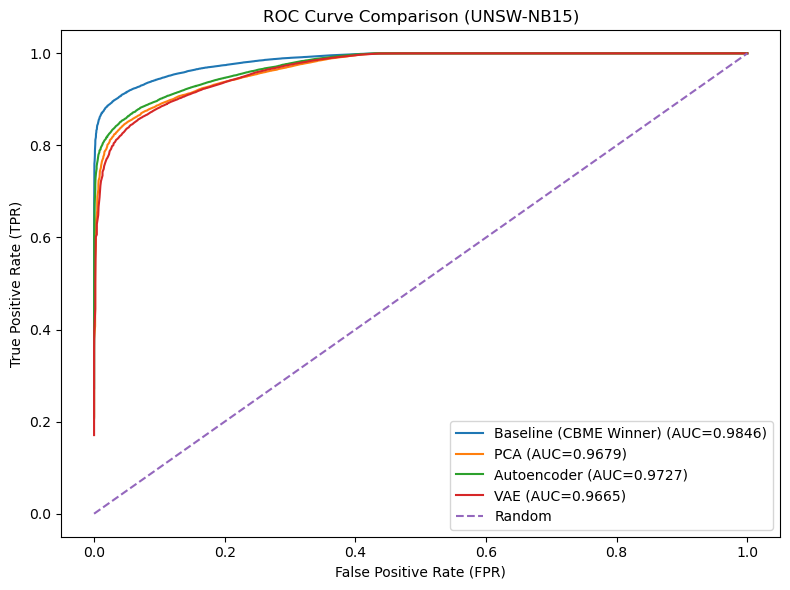

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\roc_unsw_comparison.png


In [7]:
plt.figure(figsize=(8,6))

models_unsw = [
    ("Baseline (CBME Winner)", model_unsw_base, fr_unsw_base),
    ("PCA", model_unsw_pca, fr_unsw_pca),
    ("Autoencoder", model_unsw_ae, fr_unsw_ae),
    ("VAE", model_unsw_vae, fr_unsw_vae),
]

for name, model, fr in models_unsw:
    perf = model.model_performance(fr)
    fpr, tpr = perf.roc()[0], perf.roc()[1]
    plt.plot(fpr, tpr, label=f"{name} (AUC={perf.auc():.4f})")

plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison (UNSW-NB15)")
plt.legend()
plt.tight_layout()

out = PLOTS_DIR / "roc_unsw_comparison.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


---
## Precision–Recall Curve Comparison (UNSW-NB15)

**Figure caption :**  
*Figure X: Precision–Recall curve comparison on UNSW-NB15 for Baseline (CBME winner), PCA, Autoencoder, and VAE.  
PR curves are informative under class imbalance and highlight precision–recall trade-offs across thresholds.*

Output: `outputs/plots/pr_unsw_comparison.png`


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


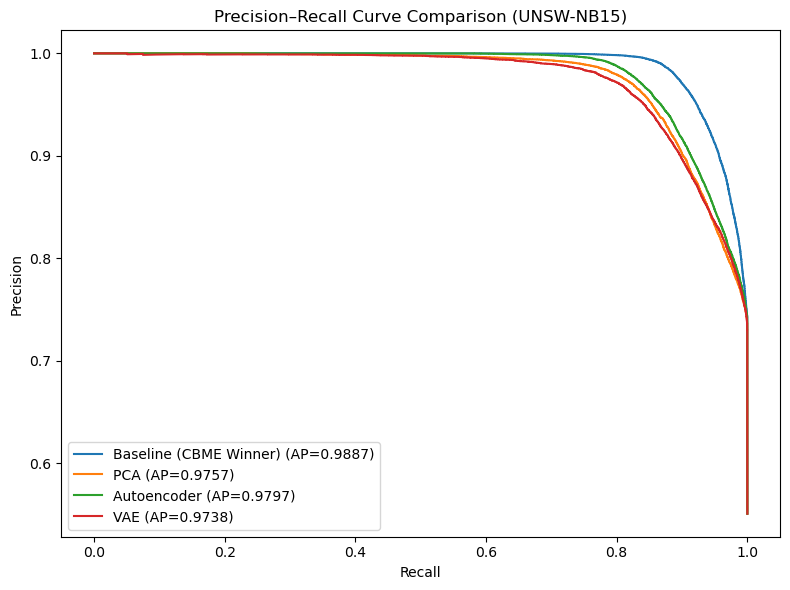

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\pr_unsw_comparison.png


In [8]:
plt.figure(figsize=(8,6))

for name, model, fr in models_unsw:
    pred = model.predict(fr).as_data_frame()
    prob_col = "p1" if "p1" in pred.columns else pred.columns[-1]

    y_score = pred[prob_col].values
    y_true = fr["label"].as_data_frame().values.ravel().astype(int)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (UNSW-NB15)")
plt.legend()
plt.tight_layout()

out = PLOTS_DIR / "pr_unsw_comparison.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


---
## Confusion Matrices at Best-F1 Threshold

We compute confusion matrices using the automatically selected best-F1 thresholds stored in metrics.

**Figure captions :**
- *Figure X: Confusion matrix for UNSW-NB15 baseline (CBME winner) at the best-F1 threshold, showing TP/FP/TN/FN counts and false alarm behaviour.*
- *Figure X: Confusion matrix for NSL-KDD best model at the best-F1 threshold, demonstrating cross-dataset performance and false positive impact.*


---
## Load NSL-KDD test frame (saved)

We load `outputs/test_frames/test_kdd.parquet` to compute NSL-KDD confusion matrix in this results notebook.


In [16]:
# Load KDD test frame if available
kdd_test_path = TEST_FRAMES_DIR / "test_kdd.parquet"

if not kdd_test_path.exists():
    print("⚠️ Missing:", kdd_test_path)
    print("Run the one-time save cell in your NSL-KDD training notebook to create it.")
else:
    df_kdd = pd.read_parquet(kdd_test_path)
    test_kdd_h2o = h2o.H2OFrame(df_kdd)
    test_kdd_h2o["label"] = test_kdd_h2o["label"].asfactor()
    print("Loaded KDD test frame:", test_kdd_h2o.shape)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Loaded KDD test frame: (22544, 62)


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


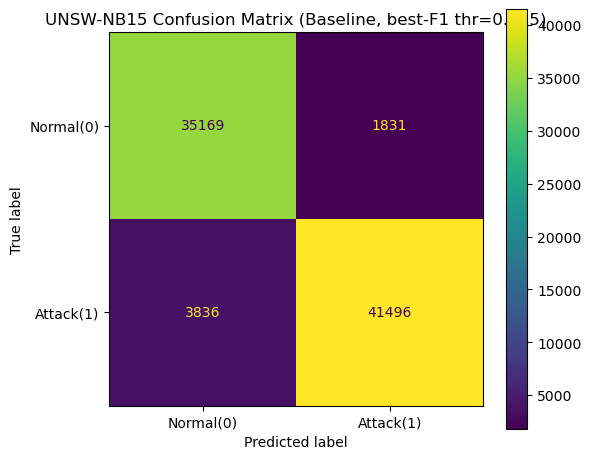

UNSW confusion: {'TN': 35169, 'FP': 1831, 'FN': 3836, 'TP': 41496}
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


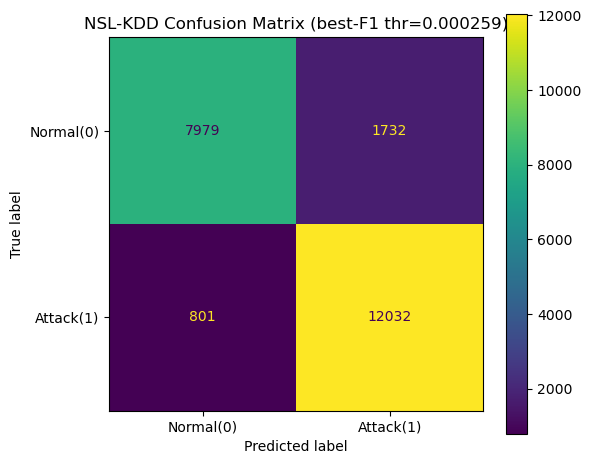

KDD confusion: {'TN': 7979, 'FP': 1732, 'FN': 801, 'TP': 12032}


In [17]:
def plot_confusion(model, fr, threshold, title, out_name):
    pred = model.predict(fr).as_data_frame()
    prob_col = "p1" if "p1" in pred.columns else pred.columns[-1]

    y_score = pred[prob_col].values
    y_true = fr["label"].as_data_frame().values.ravel().astype(int)
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal(0)","Attack(1)"])

    fig, ax = plt.subplots(figsize=(6,5))
    disp.plot(ax=ax, values_format="d")
    plt.title(title)
    plt.tight_layout()

    out = PLOTS_DIR / out_name
    plt.savefig(out, dpi=200)
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    return {"TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp)}

# UNSW baseline
cm_unsw = plot_confusion(
    model_unsw_base, fr_unsw_base, m_unsw_base["best_f1_threshold"],
    f"UNSW-NB15 Confusion Matrix (Baseline, best-F1 thr={m_unsw_base['best_f1_threshold']:.3f})",
    "confusion_unsw_baseline.png"
)
print("UNSW confusion:", cm_unsw)

# NSL-KDD (requires a test frame; rebuild quickly from saved approach if you didn’t save it yet)
# Here we assume you still have X_kdd_test_sel/y_kdd_test in training notebook.
# If not, you can skip or add a saved KDD test frame later.
try:
    test_kdd_h2o
except NameError:
    # If you previously built it in this session, keep; otherwise create a placeholder message.
    print("⚠️ test_kdd_h2o not found in this notebook session.")
    print("If you want KDD confusion here too, save a KDD test frame to outputs/test_frames and load it like UNSW.")

# If exists, plot:
if "test_kdd_h2o" in globals():
    cm_kdd = plot_confusion(
        model_kdd, test_kdd_h2o, m_kdd["best_f1_threshold"],
        f"NSL-KDD Confusion Matrix (best-F1 thr={m_kdd['best_f1_threshold']:.6f})",
        "confusion_kdd_baseline.png"
    )
    print("KDD confusion:", cm_kdd)


**Note on threshold:**  
The optimal threshold for maximising F1 on NSL-KDD was very small. This can occur when predicted probabilities are highly skewed (e.g., many samples receive low absolute probabilities while still being correctly rank-ordered). Threshold selection is therefore performed automatically based on the best-F1 criterion rather than using a fixed 0.5 cutoff.


---
## Performance Charts (UNSW-NB15)

**Figure captions :**
- *Figure X: AUC comparison across feature representations on UNSW-NB15.*
- *Figure X: F1-score comparison across feature representations on UNSW-NB15.*
- *Figure X: False positive rate (FPR) comparison across feature representations on UNSW-NB15.*

Outputs:
- `outputs/plots/perf_auc_unsw.png`
- `outputs/plots/perf_f1_unsw.png`
- `outputs/plots/perf_fpr_unsw.png`


,Pipeline,AUC,F1,FPR
0,Baseline,0.984604,0.936498,0.049432
1,PCA,0.967981,0.902377,0.075865
2,Autoencoder,0.972701,0.909273,0.070595
3,VAE,0.966411,0.899415,0.114595


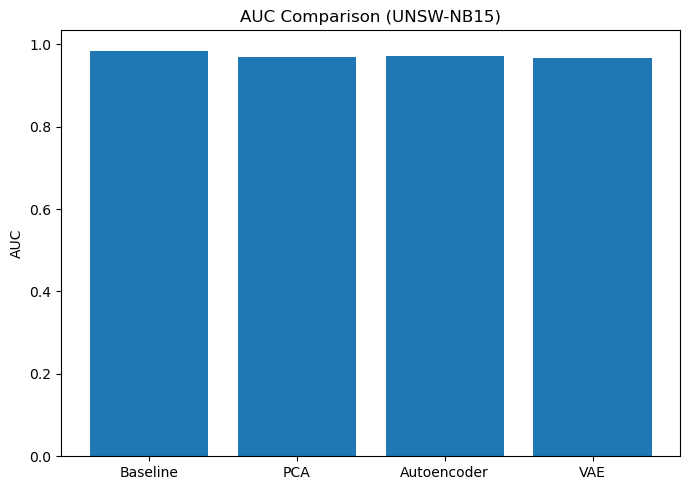

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_auc_unsw.png


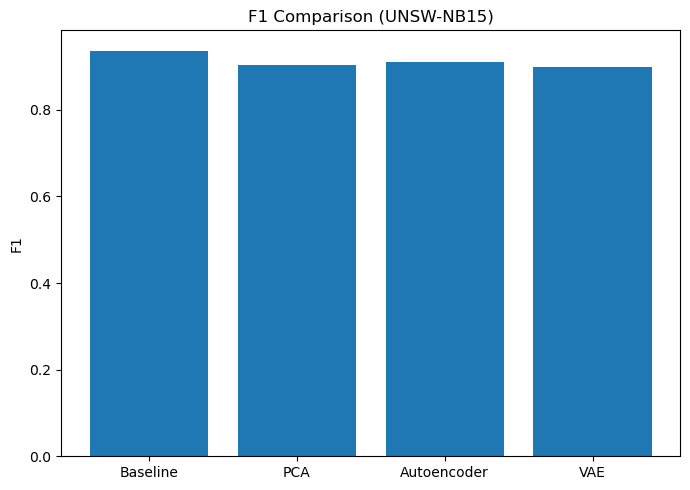

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_f1_unsw.png


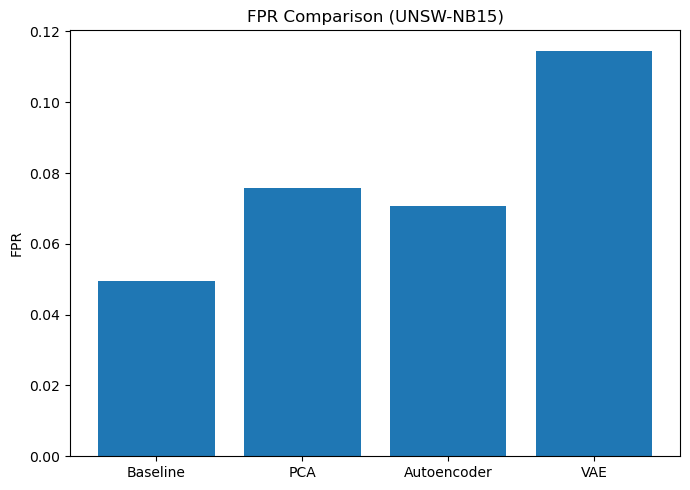

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_fpr_unsw.png


In [10]:
unsw_comp = pd.DataFrame([
    ("Baseline", m_unsw_base["AUC"], m_unsw_base["F1_at_bestF1"], m_unsw_base["FPR_at_bestF1"]),
    ("PCA", m_unsw_pca["AUC"], m_unsw_pca["F1_at_bestF1"], m_unsw_pca["FPR_at_bestF1"]),
    ("Autoencoder", m_unsw_ae["AUC"], m_unsw_ae["F1_at_bestF1"], m_unsw_ae["FPR_at_bestF1"]),
    ("VAE", m_unsw_vae["AUC"], m_unsw_vae["F1_at_bestF1"], m_unsw_vae["FPR_at_bestF1"]),
], columns=["Pipeline","AUC","F1","FPR"])

display(unsw_comp)

def bar(metric, title, out_name):
    plt.figure(figsize=(7,5))
    plt.bar(unsw_comp["Pipeline"], unsw_comp[metric])
    plt.ylabel(metric)
    plt.title(title)
    plt.tight_layout()
    out = PLOTS_DIR / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

bar("AUC", "AUC Comparison (UNSW-NB15)", "perf_auc_unsw.png")
bar("F1",  "F1 Comparison (UNSW-NB15)",  "perf_f1_unsw.png")
bar("FPR", "FPR Comparison (UNSW-NB15)", "perf_fpr_unsw.png")


---
## H2O AutoML Model Selection (Leaderboards)

**Figure captions :**
- *Figure X: H2O AutoML leaderboard (top 10 by AUC) for UNSW baseline pipeline, showing candidate models trained and the selected leader.*
- *Figure X: H2O AutoML leaderboard (top 10 by AUC) for NSL-KDD pipeline, showing AutoML search behaviour on a second dataset.*

Outputs:
- `outputs/plots/automl_leaderboard_unsw_top10.png`
- `outputs/plots/automl_leaderboard_kdd_top10.png`


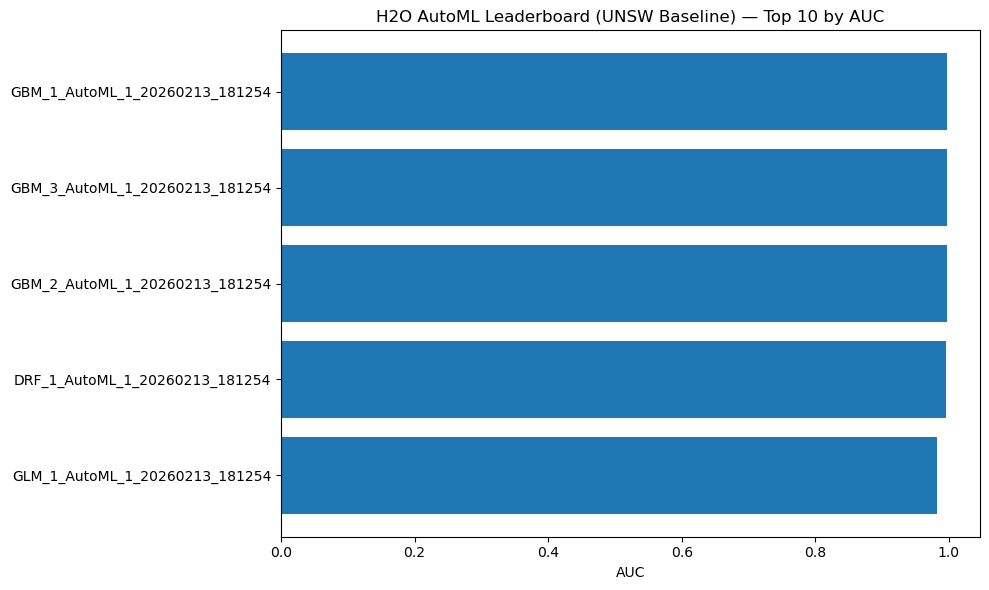

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_leaderboard_unsw_top10.png


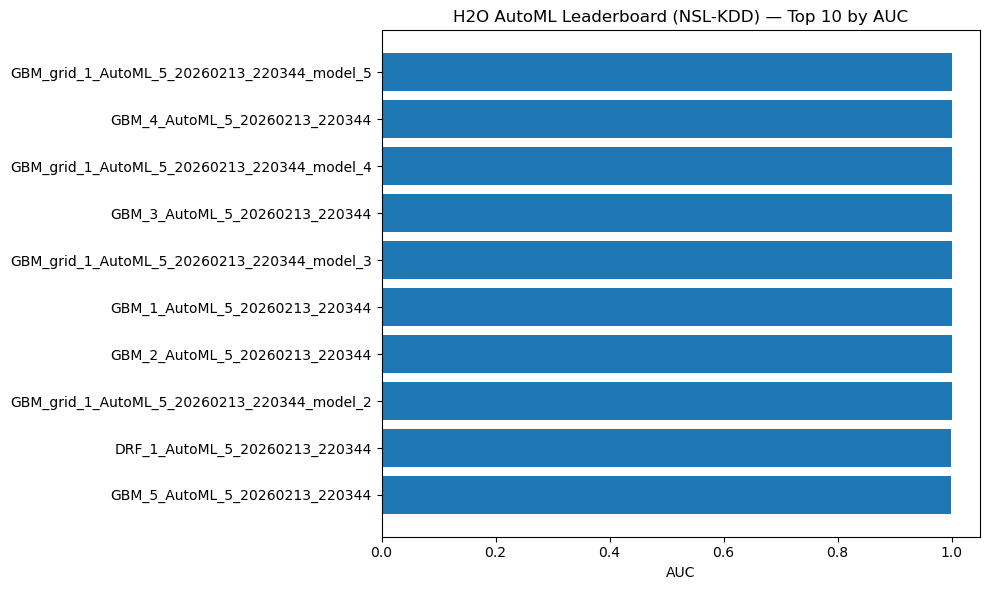

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_leaderboard_kdd_top10.png


In [11]:
def plot_leaderboard(csv_path, title, out_name, metric="auc", top_n=10):
    lb = pd.read_csv(csv_path)
    top = lb.sort_values(metric, ascending=False).head(top_n).iloc[::-1]

    plt.figure(figsize=(10,6))
    plt.barh(top["model_id"], top[metric])
    plt.xlabel(metric.upper())
    plt.title(title)
    plt.tight_layout()

    out = PLOTS_DIR / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

plot_leaderboard(
    LEADERBOARDS_DIR / "automl_leaderboard.csv",
    "H2O AutoML Leaderboard (UNSW Baseline) — Top 10 by AUC",
    "automl_leaderboard_unsw_top10.png",
    metric="auc", top_n=10
)

plot_leaderboard(
    LEADERBOARDS_DIR / "automl_leaderboard_kdd.csv",
    "H2O AutoML Leaderboard (NSL-KDD) — Top 10 by AUC",
    "automl_leaderboard_kdd_top10.png",
    metric="auc", top_n=10
)


---
## AutoML Search Summary (Models per Algorithm)

**Figure captions :**
- *Figure X: Number of AutoML models trained per algorithm family (UNSW baseline).*
- *Figure X: Number of AutoML models trained per algorithm family (NSL-KDD).*

Outputs:
- `outputs/plots/automl_model_counts_unsw.png`
- `outputs/plots/automl_model_counts_kdd.png`


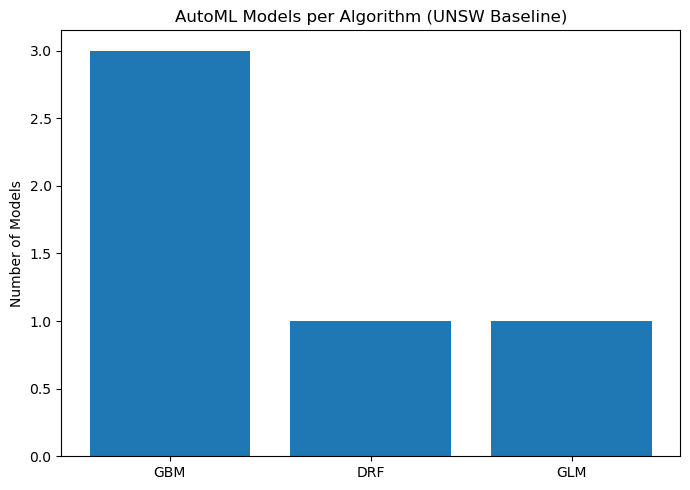

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_model_counts_unsw.png


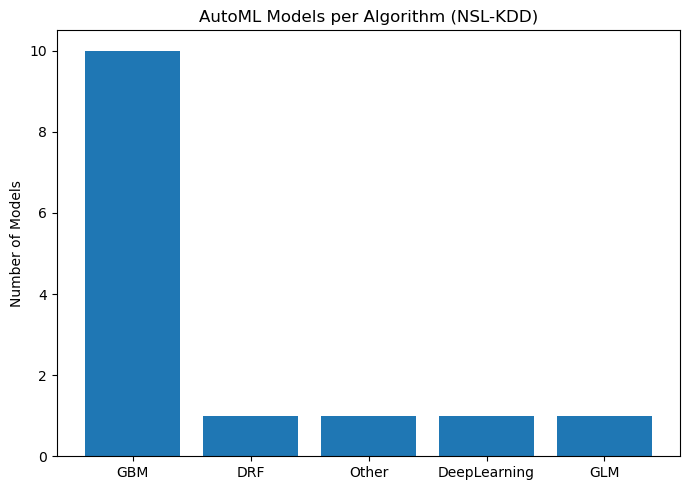

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_model_counts_kdd.png


In [12]:
def algo_from_id(mid: str):
    for a in ["StackedEnsemble", "GBM", "DRF", "GLM", "DeepLearning", "XGBoost"]:
        if str(mid).startswith(a) or a in str(mid):
            return a
    return "Other"

def plot_model_counts(csv_path, title, out_name):
    lb = pd.read_csv(csv_path)
    lb["algo"] = lb["model_id"].apply(algo_from_id)
    counts = lb["algo"].value_counts()

    plt.figure(figsize=(7,5))
    plt.bar(counts.index, counts.values)
    plt.ylabel("Number of Models")
    plt.title(title)
    plt.tight_layout()

    out = PLOTS_DIR / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

plot_model_counts(LEADERBOARDS_DIR / "automl_leaderboard.csv",
                  "AutoML Models per Algorithm (UNSW Baseline)",
                  "automl_model_counts_unsw.png")

plot_model_counts(LEADERBOARDS_DIR / "automl_leaderboard_kdd.csv",
                  "AutoML Models per Algorithm (NSL-KDD)",
                  "automl_model_counts_kdd.png")


---
## Feature Importance (CBME Winner)

**Figure caption (copy-paste):**  
*Figure X: Top-20 feature importance from the CBME-selected baseline model (UNSW-NB15), highlighting which traffic attributes contribute most to detection.*

Outputs:
- `outputs/plots/feature_importance_baseline.png`
- `outputs/features/feature_importance_baseline.csv`


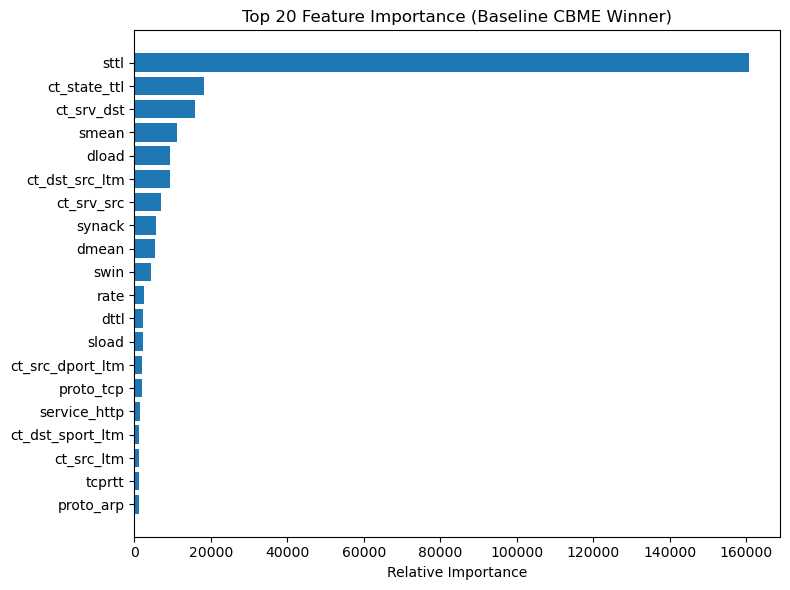

✅ Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\feature_importance_baseline.png


In [13]:
vi = model_unsw_base.varimp(use_pandas=True)
vi.to_csv(FEATURES_DIR / "feature_importance_baseline.csv", index=False)

vi_top = vi.head(20).iloc[::-1]
plt.figure(figsize=(8,6))
plt.barh(vi_top["variable"], vi_top["relative_importance"])
plt.xlabel("Relative Importance")
plt.title("Top 20 Feature Importance (Baseline CBME Winner)")
plt.tight_layout()

out = PLOTS_DIR / "feature_importance_baseline.png"
plt.savefig(out, dpi=200)
plt.show()
print("✅ Saved:", out)


---
## Mutual Information (MI) Ranking Curve

**Figure caption (copy-paste):**  
*Figure X: Cumulative mutual information contribution curve showing how information accumulates as features are added in ranked order, supporting the automated feature selection strategy.*

Output:
- `outputs/plots/mi_ranking_curve.png`


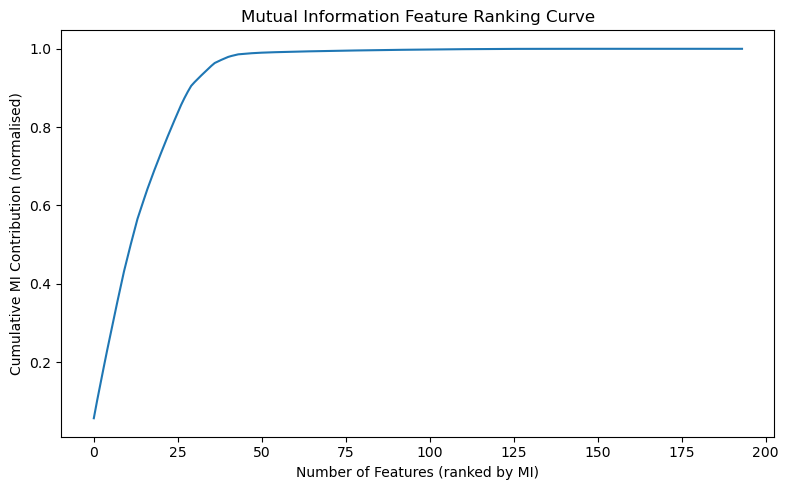

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\mi_ranking_curve.png


In [14]:
mi_df = pd.read_csv(FEATURES_DIR / "mutual_information_ranking.csv")
mi_df["cumulative"] = mi_df["mi_score"].cumsum()
mi_df["cumulative_norm"] = mi_df["cumulative"] / (mi_df["cumulative"].max() + 1e-12)

plt.figure(figsize=(8,5))
plt.plot(range(len(mi_df)), mi_df["cumulative_norm"])
plt.xlabel("Number of Features (ranked by MI)")
plt.ylabel("Cumulative MI Contribution (normalised)")
plt.title("Mutual Information Feature Ranking Curve")
plt.tight_layout()

out = PLOTS_DIR / "mi_ranking_curve.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


---
## Results Summary (Dissertation-Ready)

**Summary paragraph :**  
Across UNSW-NB15, the checkpoint-based elimination (CBME) procedure selected the mutual-information (MI) feature selection pipeline as the optimal configuration. This baseline achieved the strongest overall discrimination (AUC) and the highest F1-score while maintaining the lowest false positive rate compared with PCA, Autoencoder, and VAE latent representations. Latent-feature approaches produced competitive results but slightly reduced performance, likely because reconstruction/variance objectives do not directly optimise class separability. Cross-dataset validation on NSL-KDD demonstrates that the automated pipeline remains effective on a second benchmark dataset without manual tuning, supporting the generalisability of the proposed methodology.


---
---
# Step N13 — AutoML Intrusion Detection Pipeline Diagram

## What we are doing
We generate a visual diagram of the automated pipeline including:

- Data loading
- Automated preprocessing
- SMOTE balancing
- Feature-centric representations:
    - Mutual Information selection
    - PCA
    - Autoencoder
    - VAE
- AutoML model selection
- CBME model elimination
- Final evaluation

## Why we are doing it
This diagram illustrates the overall system architecture and is suitable for inclusion
in the Methodology section of the dissertation.

## Output
- outputs/plots/automl_ids_pipeline_diagram.png


In [3]:
from pathlib import Path

# Define project directories
BASE_DIR = Path.cwd().parent   # assumes notebook is in AutoML/notebooks/
OUTPUT_DIR = BASE_DIR / "outputs"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: C:\Users\sohib\Documents\Final Year Project\AutoML
OUTPUT_DIR: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs


In [4]:
from graphviz.backend import dot_command
dot_command.DOT_BINARY = r"C:\Program Files\Graphviz\bin\dot.exe"


✅ Saved pipeline diagram to:
C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_ids_pipeline_diagram.svg


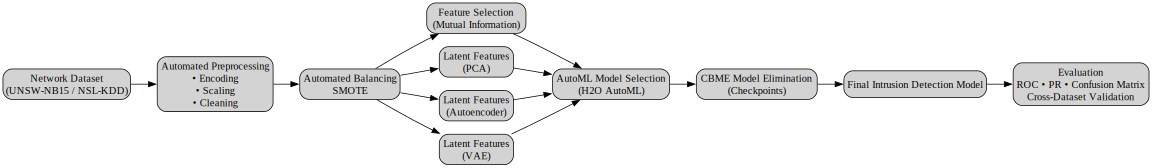

In [5]:
from graphviz import Digraph
from pathlib import Path

# Ensure output directory exists
PLOTS_DIR = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Create diagram (SVG = no blur ever)
dot = Digraph(format="svg")

# Global graph settings
dot.attr(rankdir="LR", size="16,8")
dot.attr(fontsize="12")
dot.attr("node", shape="box", style="rounded,filled", fillcolor="lightgray")

# Nodes
dot.node("A", "Network Dataset\n(UNSW-NB15 / NSL-KDD)")
dot.node("B", "Automated Preprocessing\n• Encoding\n• Scaling\n• Cleaning")
dot.node("C", "Automated Balancing\nSMOTE")

dot.node("D1", "Feature Selection\n(Mutual Information)")
dot.node("D2", "Latent Features\n(PCA)")
dot.node("D3", "Latent Features\n(Autoencoder)")
dot.node("D4", "Latent Features\n(VAE)")

dot.node("E", "AutoML Model Selection\n(H2O AutoML)")
dot.node("F", "CBME Model Elimination\n(Checkpoints)")
dot.node("G", "Final Intrusion Detection Model")
dot.node("H", "Evaluation\nROC • PR • Confusion Matrix\nCross-Dataset Validation")

# Edges
dot.edge("A", "B")
dot.edge("B", "C")

dot.edge("C", "D1")
dot.edge("C", "D2")
dot.edge("C", "D3")
dot.edge("C", "D4")

dot.edge("D1", "E")
dot.edge("D2", "E")
dot.edge("D3", "E")
dot.edge("D4", "E")

dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")

# Save
out_path = str(PLOTS_DIR / "automl_ids_pipeline_diagram")
dot.render(out_path, cleanup=True)

print("✅ Saved pipeline diagram to:")
print(out_path + ".svg")

dot

Figure X illustrates the proposed AutoML-based intrusion detection framework. The pipeline begins with automated preprocessing and class balancing using SMOTE. Feature-centric representations are then generated using mutual information feature selection, PCA, autoencoder, and VAE methods. Each representation is evaluated using H2O AutoML, which automatically selects the best-performing model. A checkpoint-based model elimination (CBME) strategy compares performance across representations and selects the optimal configuration. The final model is evaluated using ROC curves, Precision–Recall curves, confusion matrices, and cross-dataset validation to ensure robustness and generalisation.

---
---
# Step N14 — SHAP Explainability Analysis (H2O Native)

## What we are doing
We compute SHAP-style contribution values using H2O's native `predict_contributions()` for the
final selected UNSW baseline model.

## Why we are doing it
This provides interpretability for the AutoML-selected model by ranking features according to
their average absolute contribution to predictions.

## Notes
- This is **post-training explainability** (does not change the AutoML pipeline).
- We use the same **baseline test frame** used for evaluation: `test_baseline.parquet`.

## Output
- outputs/plots/shap_importance_h2o.png
- outputs/features/shap_importance_h2o.csv


C:\Users\sohib\AppData\Local\Temp\ipykernel_1312\805320737.py:22: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().show_status(True)``.
  h2o.cluster_status()


H2O_cluster_uptime:,8 hours 48 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 20 days
H2O_cluster_name:,H2O_from_python_sohib_0caiiv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.318 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Nodes info:,Node 1
h2o,/127.0.0.1:54321
healthy,True
last_ping,1771031240943.0000000
num_cpus,8
sys_load,0.2344314
mem_value_size,1290997888.0000000
free_mem,2488558384.0000000
pojo_mem,433622096
swap_mem,0
free_disk,367102263296.0000000


✅ Using UNSW baseline leader model: GBM_1_AutoML_1_20260213_181254
✅ Model loaded: GBM_1_AutoML_1_20260213_181254
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
contributions progress: |████████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


✅ Contributions shape: (82332, 98)
Columns (first 10): ['sbytes', 'smean', 'sttl', 'sload', 'rate', 'dbytes', 'ct_state_ttl', 'dur', 'dttl', 'dmean']
✅ Saved SHAP importance table: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\features\shap_importance_h2o.csv


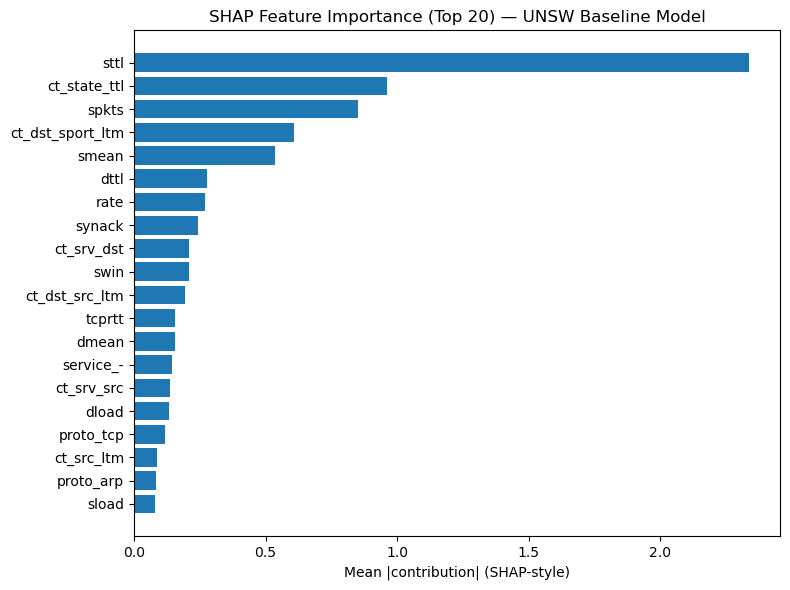

✅ Saved SHAP plot: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\shap_importance_h2o.png


In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h2o
from pathlib import Path

# ---- Paths (define if not already defined in notebook) ----
BASE_DIR = Path.cwd().parent
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"
TEST_FRAMES_DIR = OUTPUT_DIR / "test_frames"
FEATURES_DIR = OUTPUT_DIR / "features"
MODELS_DIR = OUTPUT_DIR / "models_saved"

for d in [PLOTS_DIR, FEATURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- H2O init ----
try:
    h2o.cluster_status()
except:
    h2o.init()

# ---- Load UNSW baseline leader model id (reliable) ----
m_unsw_base = json.load(open(METRICS_DIR / "test_metrics_bestF1.json"))
MODEL_ID = m_unsw_base["leader_model_id"]
print("✅ Using UNSW baseline leader model:", MODEL_ID)

# ---- Load model (try cluster first, then disk) ----
try:
    best_model = h2o.get_model(MODEL_ID)
except:
    # load from saved models folder if not in cluster
    # find any saved file containing model id
    candidates = list(MODELS_DIR.rglob(f"*{MODEL_ID}*"))
    if not candidates:
        raise FileNotFoundError(f"Model {MODEL_ID} not found in H2O or {MODELS_DIR}")
    best_model = h2o.load_model(str(candidates[0]))

print("✅ Model loaded:", best_model.model_id)

# ---- Load UNSW baseline test frame (the one you actually saved) ----
test_path = TEST_FRAMES_DIR / "test_baseline.parquet"
if not test_path.exists():
    raise FileNotFoundError(f"Missing {test_path}. Check outputs/test_frames/ folder.")

df_test = pd.read_parquet(test_path)

# Convert to H2OFrame
test_h2o = h2o.H2OFrame(df_test)
test_h2o["label"] = test_h2o["label"].asfactor()

# IMPORTANT: predict_contributions should not include the label column
x_cols = [c for c in test_h2o.columns if c != "label"]

# ---- Compute SHAP-like contributions ----
contrib = best_model.predict_contributions(test_h2o[x_cols])
contrib_df = contrib.as_data_frame()

print("✅ Contributions shape:", contrib_df.shape)
print("Columns (first 10):", list(contrib_df.columns[:10]))

# Remove BiasTerm if present
if "BiasTerm" in contrib_df.columns:
    contrib_df_no_bias = contrib_df.drop(columns=["BiasTerm"])
else:
    contrib_df_no_bias = contrib_df

# Mean absolute contribution per feature (global importance)
importance = np.abs(contrib_df_no_bias).mean().sort_values(ascending=False)
imp_df = importance.reset_index()
imp_df.columns = ["feature", "mean_abs_shap"]

# Save table
out_csv = FEATURES_DIR / "shap_importance_h2o.csv"
imp_df.to_csv(out_csv, index=False)
print("✅ Saved SHAP importance table:", out_csv)

# Plot top 20
topn = 20
plt.figure(figsize=(8,6))
plot_df = imp_df.head(topn).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |contribution| (SHAP-style)")
plt.title("SHAP Feature Importance (Top 20) — UNSW Baseline Model")
plt.tight_layout()

out_img = PLOTS_DIR / "shap_importance_h2o.png"
plt.savefig(out_img, dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved SHAP plot:", out_img)


Dissertation interpretation paragraph 

SHAP analysis was applied to the final AutoML-selected baseline model to provide interpretability and transparency. The global feature importance ranking shows that features such as sbytes, smean, sttl, sload, and rate have the highest contribution to model predictions. These features represent key network traffic characteristics including transmitted bytes, packet statistics, and protocol behaviour. High SHAP importance indicates that these features strongly influence whether traffic is classified as normal or malicious. This demonstrates that the AutoML-selected model relies on meaningful network-level attributes rather than arbitrary correlations. The use of SHAP enhances trust in the automated intrusion detection system by providing insight into how detection decisions are made.